In [1]:
%cd ../..

/Users/katyscott/Documents/BHKLab_GitHub/ocscc_tumor_characterization


In [2]:
import pandas as pd
from damply import dirs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Process decisions to make experiment results csv

In [3]:
decision_df = pd.read_excel(dirs.RESULTS / "RADCURE_OCSCC/OCSCC_surgery_decision_sheet.xlsx", 
                            header=[1], index_col=0)

gt_pats = pd.read_csv(dirs.PROCDATA / "RADCURE_OCSCC/metadata/gt_patient_list.csv", names=['SampleID'])
pred_pats = pd.read_csv(dirs.PROCDATA / "RADCURE_OCSCC/metadata/pred_patient_list.csv", names=['SampleID'])

2026-05-26 | WARNING | Environment variable 'RESULTS' is not set. Using default path relative to project root.
2026-05-26 | WARNING | Environment variable 'PROCDATA' is not set. Using default path relative to project root.


In [4]:
decision_df = decision_df.fillna(0)
decision_df = decision_df.replace('x',1)
decision_df = decision_df.replace('X',1)

/var/folders/71/rrp6j9vj3tv1mc89c__4w9bc0000gn/T/ipykernel_48982/2289564697.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  decision_df = decision_df.replace('x',1)
/var/folders/71/rrp6j9vj3tv1mc89c__4w9bc0000gn/T/ipykernel_48982/2289564697.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  decision_df = decision_df.replace('X',1)


In [5]:
first_round = decision_df.iloc[0:97].copy()
second_round = decision_df.iloc[97:].reset_index(drop=True).copy()
second_round.index = first_round.index

In [6]:
first_round['Decision'] = first_round.loc[:,[('Yes'), ('No'), ('Maybe')]].idxmax(axis=1)
first_round = first_round.drop(columns=['Yes','No','Maybe'])
first_round = first_round

second_round['Decision'] = second_round.loc[:,[('Yes'), ('No'), ('Maybe')]].idxmax(axis=1)
second_round = second_round.drop(columns=['Yes','No','Maybe'])

In [7]:
ground_truth_results = pd.concat([first_round.loc[gt_pats.SampleID, ['Decision', 'Notes']], second_round.loc[pred_pats.SampleID, ['Decision', 'Notes']]])
ground_truth_results.columns = ['GT_Decision', 'GT_Notes']

pred_results = pd.concat([second_round.loc[gt_pats.SampleID, ['Decision', 'Notes']], first_round.loc[pred_pats.SampleID, ['Decision', 'Notes']]])
pred_results.columns = ['Pred_Decision', 'Pred_Notes']

In [8]:
experiment_results = pd.merge(ground_truth_results, pred_results, left_index=True, right_index=True)

In [9]:
experiment_results['Match'] = experiment_results['GT_Decision'] == experiment_results['Pred_Decision']

In [ ]:
experiment_results.to_csv(dirs.RESULTS / "RADCURE_OCSCC/experiment_results.csv")

# Load and work with experiment results

In [3]:
experiment_results = pd.read_csv(dirs.RESULTS / "RADCURE_OCSCC/experiment_results.csv", index_col=0)

2026-05-26 | WARNING | Environment variable 'RESULTS' is not set. Using default path relative to project root.


In [4]:
experiment_results

,GT_Decision,GT_Notes,Pred_Decision,Pred_Notes,Match
SampleID,,,,,
RADCURE-0014_0008,Yes,Hemiglossectomy,No,"Hemitongue, palate, tonsil",False
RADCURE-0296_0233,Maybe,Total palatectomy - probably only if p16-,No,"total tongue, bilateral tonsil, total soft pal...",False
RADCURE-0326_0259,Yes,subtotal glossectomy,Yes,hemiglossectomy,True
RADCURE-0338_0270,Yes,subtotal glossectomy,Yes,subtotal glossectomy,True
RADCURE-0367_0292,Yes,Lip resection,Yes,Lip,True
...,...,...,...,...,...
RADCURE-3091_2456,Yes,tonsil miniminal soft palate extension,Maybe,Left Oropharynx cancer (may not be amenable to...,False
RADCURE-3118_2480,Yes,anterior mandibulectomy,Yes,Left Mandibulectomy,True
RADCURE-3268_2622,Yes,anterior mandibulectomy,Yes,Anterior Lip,True


In [13]:
experiment_results.GT_Decision.value_counts()

GT_Decision
Yes      68
Maybe    21
No        8
Name: count, dtype: int64

In [ ]:
experiment_results.Match.value_counts()

Match
True     67
False    30
Name: count, dtype: int64

In [ ]:
experiment_results[(experiment_results['GT_Decision'] == 'No') & (experiment_results['Pred_Decision'] == 'Maybe')]

,GT_Decision,GT_Notes,Pred_Decision,Pred_Notes,Match
SampleID,,,,,
RADCURE-0859_0682,No,only if p16- oropharynx cancer with hemi soft...,Maybe,"salvage only (left oropharynx, tonsil, with pa...",False
RADCURE-0930_0733,No,"oropharynx with extension to pterygoids, skull...",Maybe,"tonsil, nasopharynx, skull base",False
RADCURE-1977_1455,No,Oropharynx with involvment of nasopharynx,Maybe,"hemisoft palate, tonsil,",False


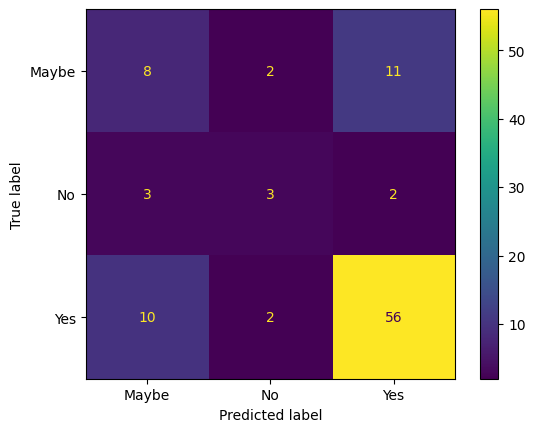

In [14]:
y_true = experiment_results['GT_Decision'].to_list()
y_pred = experiment_results['Pred_Decision'].to_list()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['Maybe', 'No', 'Yes'])
disp.plot(cmap=plt.cm.viridis)
plt.show()

In [6]:
exp_results_v2 = experiment_results.copy()

exp_results_v2['GT_Decision'] = ['Yes' if val == 'Maybe' else val for val in exp_results_v2['GT_Decision'] ]
exp_results_v2['Pred_Decision'] = ['Yes' if val == 'Maybe' else val for val in exp_results_v2['Pred_Decision'] ]

In [9]:
exp_results_v2

,GT_Decision,GT_Notes,Pred_Decision,Pred_Notes,Match
SampleID,,,,,
RADCURE-0014_0008,Yes,Hemiglossectomy,No,"Hemitongue, palate, tonsil",False
RADCURE-0296_0233,Yes,Total palatectomy - probably only if p16-,No,"total tongue, bilateral tonsil, total soft pal...",False
RADCURE-0326_0259,Yes,subtotal glossectomy,Yes,hemiglossectomy,True
RADCURE-0338_0270,Yes,subtotal glossectomy,Yes,subtotal glossectomy,True
RADCURE-0367_0292,Yes,Lip resection,Yes,Lip,True
...,...,...,...,...,...
RADCURE-3091_2456,Yes,tonsil miniminal soft palate extension,Yes,Left Oropharynx cancer (may not be amenable to...,False
RADCURE-3118_2480,Yes,anterior mandibulectomy,Yes,Left Mandibulectomy,True
RADCURE-3268_2622,Yes,anterior mandibulectomy,Yes,Anterior Lip,True


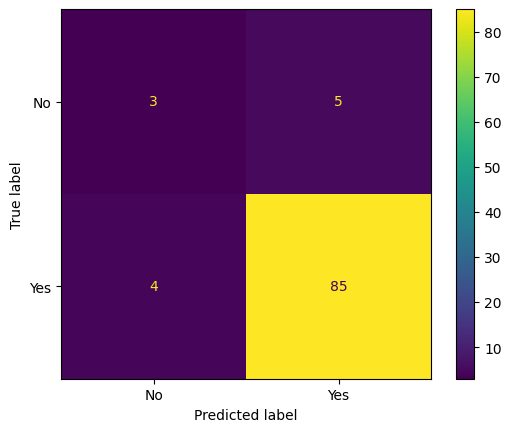

In [15]:
y_true = exp_results_v2['GT_Decision'].to_list()
y_pred = exp_results_v2['Pred_Decision'].to_list()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['No', 'Yes'])
disp.plot(cmap=plt.cm.viridis)
plt.show()